In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('old_cars.csv')
data

,Car,MPG,Displacement,Horsepower,Weight,Model,Origin
0,AMC Ambassador Brougham,13.0,360.0,175,3821,73,US
1,AMC Ambassador DPL,15.0,390.0,190,3850,70,US
2,AMC Ambassador SST,17.0,304.0,150,3672,72,US
3,AMC Concord,19.4,232.0,90,3210,78,US
4,AMC Concord,24.3,151.0,90,3003,80,US
...,...,...,...,...,...,...,...
393,Volvo 145e (sw),18.0,121.0,112,2933,72,Europe
394,Volvo 244DL,22.0,121.0,98,2945,75,Europe
395,Volvo 245,20.0,130.0,102,3150,76,Europe
396,Volvo 264gl,17.0,163.0,125,3140,78,Europe


1. Distribution gas mileage with regions, so X adalah regions atau pada dataset adalah Origin, sedangkan Y adalah rata-rata mileage (MPG)

C:\Users\COMPUTER\AppData\Local\Temp\ipykernel_20300\2382125329.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Origin', y='MPG', data=rata_mpg, palette='viridis')


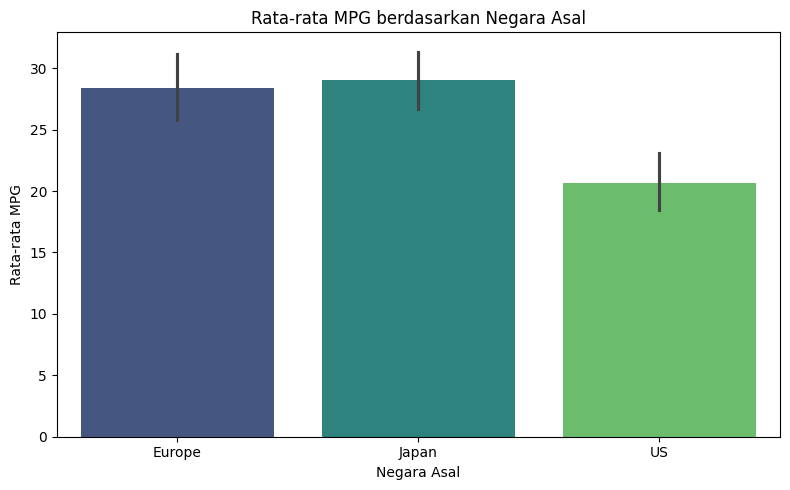

In [4]:
#rata-rata MPG jika dilihat dengan Origin
rata_mpg = data.groupby(['Origin', 'Model'])['MPG'].mean().reset_index()

#Membuat bar chart
plt.figure(figsize=(8, 5)) #ukuran figure
sns.barplot(x='Origin', y='MPG', data=rata_mpg, palette='viridis')

#Menambahkan judul dan label
plt.title('Rata-rata MPG berdasarkan Negara Asal')
plt.xlabel('Negara Asal')
plt.ylabel('Rata-rata MPG')
plt.tight_layout()

#Menampilkan grafik
plt.show()

In [5]:
jumlahmodel = data['Model'].value_counts().reset_index()
jumlahmodel

,Model,count
0,73,40
1,78,36
2,76,34
3,82,31
4,75,30
5,81,29
6,80,29
7,70,29
8,79,29
9,72,28


Insight yang didapatkan dari chart tersebut adalah rata-rata MPG tertinggi berasal dari Japan, sedangkan rata-rata MPG terendah berasal dari US. Setelah mengetahui insight tersebut perlu dilakukan breakdown dan analisis lebih lanjut mengenai faktor, alasan, dan research secara mendalam bagaimana hal tersebut bisa terjadi. Mari kita breakdown pertahunnya pada chart lanjutan di bawah ini.

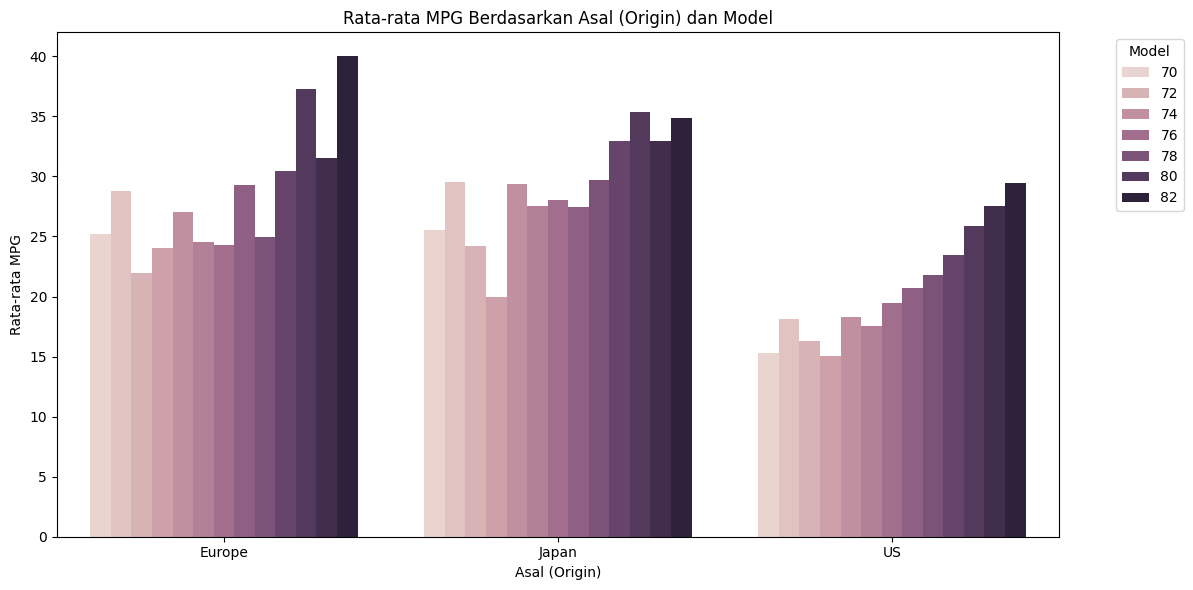

In [6]:
#rata-rata MPG jika dilihat melalui negara lengkap dengan per tahunnya selama 1970-1982
rata_mpg_tahun = data.groupby(['Origin', 'Model'])['MPG'].mean().reset_index() #penggelompokan data, 
#reset_index agar hasilnya kembali ke dataframe

jumlahmodel = data['Model'].sum()

#Membuat grafik bar
plt.figure(figsize=(12, 6)) #ukuran figure
sns.barplot(data=rata_mpg_tahun, x='Origin', y='MPG', hue='Model') 
#hue untuk dikelompokkan berdasarkan Model dengan warna yang berbeda

#Menambahkan judul dan label
plt.title('Rata-rata MPG Berdasarkan Asal (Origin) dan Model')
plt.xlabel('Asal (Origin)')
plt.ylabel('Rata-rata MPG')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
#bbox_to_anchor untuk tempat legend(x,y), loc untuk tempat lokasi legend
plt.tight_layout() #mengatur layout agar rapi dan tidak tumpang tindih

#Menampilkan grafik
plt.show() 

Setelah dibreakdown setiap tahun, dari chart tersebut kita bisa mengetahui tren atau pola rata-rata MPG setiap negara dan setiap tahunnya. Setiap warna merepresentasikan setiap tahun(dapat dilihat pada legend). Sebelumnya kita mengetahui bahwa rata-rata MPG pada Europe dan Japan tidak begitu jauh, namun Japan menjadi negara dengan rata-rata MPG tertinggi karena setiap tahunnya Japan cenderung lebih stabil berbeda dengan Europe yang naik turun dan fluktuatif.

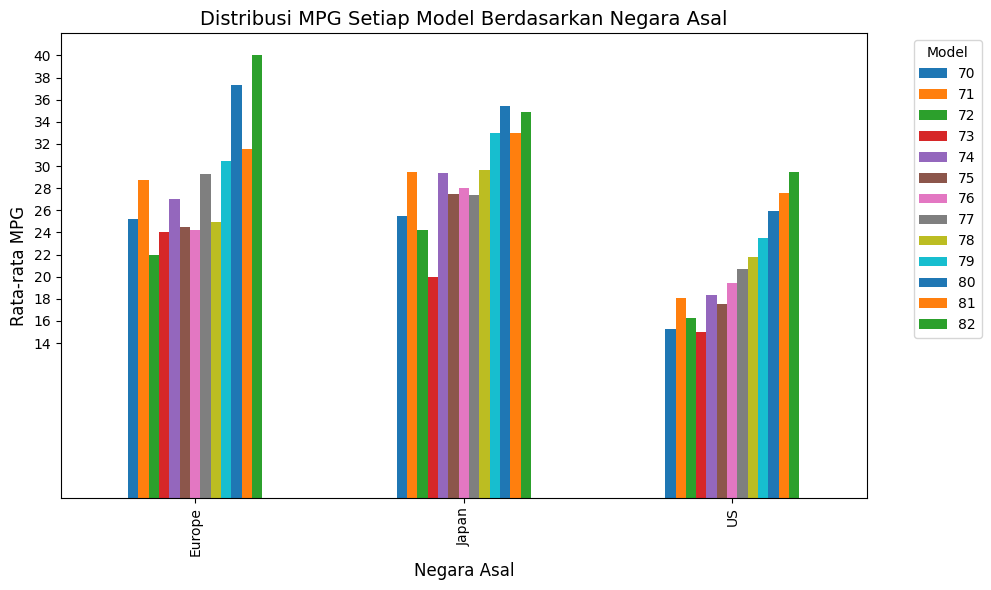

In [13]:
avg_mpg_model = data.groupby(['Origin', 'Model'])['MPG'].mean().unstack()

#menghitung rata-rata MPG terendah dan tertinggi dari setiap negara asal
y_min = np.floor(avg_mpg_model.min().min() / 2) * 2  # Kelipatan genap terdekat dari rata-rata terendah
y_max = np.ceil(avg_mpg_model.max().max() / 2) * 2  # Kelipatan genap terdekat dari rata-rata tertinggi

avg_mpg_model.plot(kind='bar', figsize=(10, 6))
plt.title('Distribusi MPG Setiap Model Berdasarkan Negara Asal', fontsize=14)
plt.xlabel('Negara Asal', fontsize=12)
plt.ylabel('Rata-rata MPG', fontsize=12)

#mengatur ticks pada sumbu Y agar hanya kelipatan 2 yang genap, dimulai dari y_min dan diakhiri y_max
plt.yticks(np.arange(y_min, y_max + 2, 2))
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Chart tersebut menampilkan mobil dari berbagai negara lengkap dengan tahun(legend) dan rata-rata MPG setiap mobilnya

C:\Users\COMPUTER\AppData\Local\Temp\ipykernel_41692\407393915.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(['MPG_range', 'Origin']).size().unstack(fill_value=0)


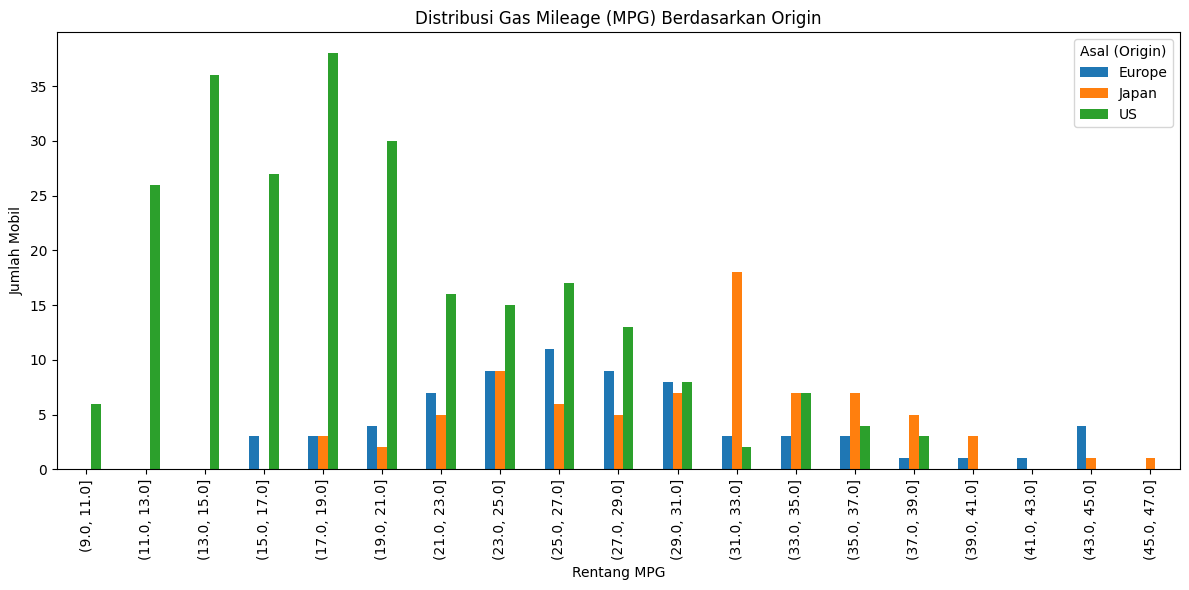

In [6]:
#mencoba membuat mirip seperti word dengan sb x MPG, sb Y jumlah mobil

bins = np.arange(data['MPG'].min(), data['MPG'].max() +2, 2) #untuk sb x berbentuk range
#membuat range dengan arange menggunakan data min dan max
# +2 memastikan bahwa range terdiri dari min dan max, sedangkan 2 terakhir untuk jarak intervalnya

data['MPG_range'] = pd.cut(data['MPG'], bins=bins)
#pd.cut untuk memotong hasil kategori bins dan membuat tabel baru(karena berdasarkan rangenya)

#mengelompokkan data berdasarkan rentang MPG dan Origin, 
#lalu menghitung jumlah mobil setiap negara menggunakan size
#unstack digunakan untuk mengubah struktur baris agar setiap MPG Range terkoneksi sebaris dengan country
#dan jika ada yang kosong akan diisi dengan nol
grouped_data = data.groupby(['MPG_range', 'Origin']).size().unstack(fill_value=0)

#membuat grafik bar terkelompok
grouped_data.plot(kind='bar', figsize=(12, 6)) #menggunakan bar char dan menetapkan ukuran figure

# Menambahkan judul dan label
plt.title('Distribusi Gas Mileage (MPG) Berdasarkan Origin')
plt.xlabel('Rentang MPG')
plt.ylabel('Jumlah Mobil')
plt.legend(title='Asal (Origin)', loc='upper right')

# Menampilkan grafik
plt.tight_layout()
plt.show()


Pada Chart tersebut bisa terlihat jumlah mobil yang memiliki rentang MPG masing-masing lengkap dengan informasi negaranya juga.

Dari chart tersebut kita bisa melihat penyebaran MPG setiap mobil pada setiap negara(Origin) juga

In [7]:
data['MPG_range'].reset_index() #tampilan hasil MPG_range

,index,MPG_range
0,0,"(11.0, 13.0]"
1,1,"(13.0, 15.0]"
2,2,"(15.0, 17.0]"
3,3,"(19.0, 21.0]"
4,4,"(23.0, 25.0]"
...,...,...
393,393,"(17.0, 19.0]"
394,394,"(21.0, 23.0]"
395,395,"(19.0, 21.0]"
396,396,"(15.0, 17.0]"


In [8]:
grouped_data #ini output jumlah mobil setiap negara dengan MPG Rangenya

Origin,Europe,Japan,US
MPG_range,,,
"(9.0, 11.0]",0,0,6
"(11.0, 13.0]",0,0,26
"(13.0, 15.0]",0,0,36
"(15.0, 17.0]",3,0,27
"(17.0, 19.0]",3,3,38
"(19.0, 21.0]",4,2,30
"(21.0, 23.0]",7,5,16
"(23.0, 25.0]",9,9,15
"(25.0, 27.0]",11,6,17


2. Visualisasikan rata-rata MPG setiap negaranya dan tampilkan per tahunnya menggunakan line chart

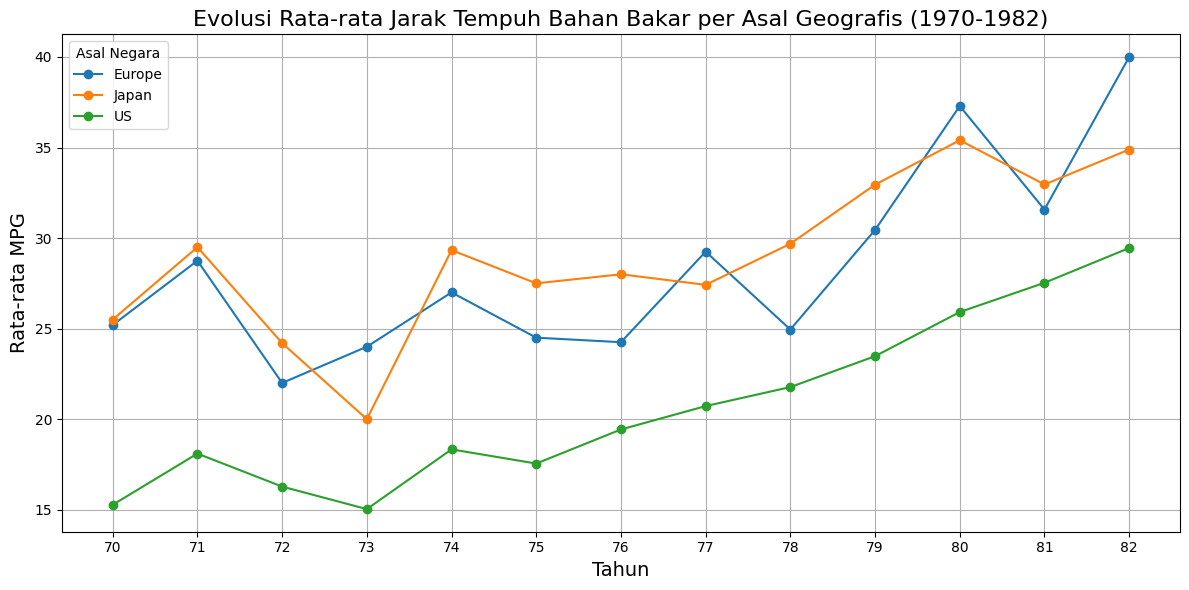

In [9]:
grouptahun = data.groupby(['Model', 'Origin'])['MPG'].mean().unstack() #menggelompokkan data
plt.figure(figsize=(12, 6)) #ukuran figure

for origin in grouptahun.columns: #melooping setiap kolom pada grouptahun
    plt.plot(grouptahun.index, grouptahun[origin], marker='o', label=origin)
    #index menjadikan sumbu X, [origin] untuk menjadikan sumbu y, marker untuk penandanya, label untuk legendnya

plt.xticks(grouptahun.index)  #membuat setiap tahun yang muncul menjadi sumbu X
plt.xlabel('Tahun', fontsize=14) #label atau nama di bawah sumbu X
plt.ylabel('Rata-rata MPG', fontsize=14) #label atau nama di bawah sumbu Y
plt.title('Evolusi Rata-rata Jarak Tempuh Bahan Bakar per Asal Geografis (1970-1982)', fontsize=16) #judul
plt.legend(title='Asal Negara') #judul untuk legend
plt.grid() #menambahkan garis di latar belakang
plt.tight_layout()  #memastikan layout tidak terpotong
plt.show()

Chart diatas hampir sama seperti no 1 bagian akhir, namun pada line chart dapat terlihat jelas tren naik turun rata-rata MPG setiap negara. Dapat terlihat lebih jelas juga bahwa Japan kenaikan dan penurunannya lebih stabil dibandingkan Europe

3. Visualisasikan hubungan Hourse power(X) dan MPG(Y) menggunakan scatterplot

In [10]:
daftarmobil = data['Car'].value_counts().reset_index()
daftarmobil

,Car,count
0,Toyota Corolla,9
1,Ford Pinto,6
2,Ford Maverick,5
3,AMC Matador,5
4,Volkswagen Rabbit,5
...,...,...
296,Volkswagen 1131 Deluxe Sedan,1
297,Volkswagen 411 (sw),1
298,Toyota Corolla 1600 (sw),1
299,Volkswagen Dasher (diesel),1


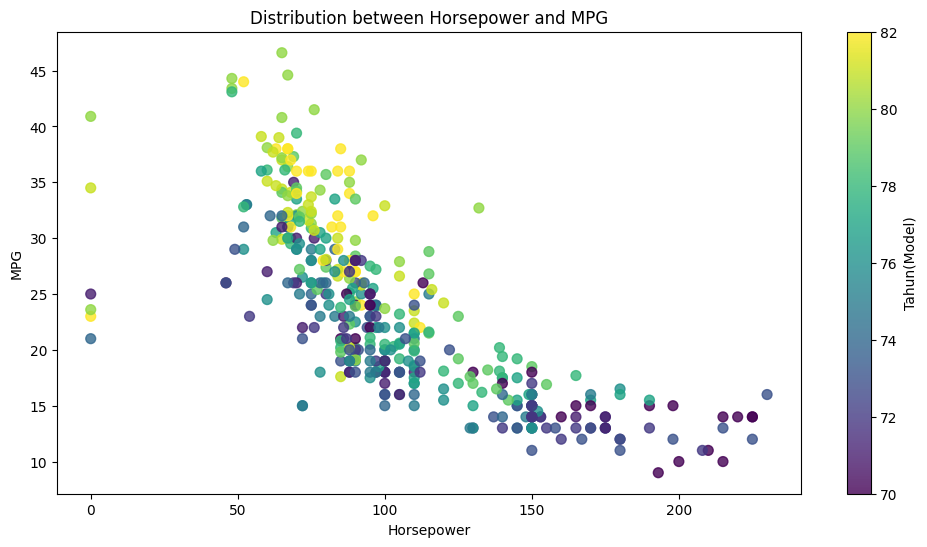

In [11]:
#3. Hubungan antara horsepower dengan MPG yang dilihat tahunnya
plt.figure(figsize=(12, 6))  #ukuran figure

scatterplot = plt.scatter(data['Horsepower'], data['MPG'], c=data['Model'], cmap='viridis', alpha=0.8, s=50)
#membuat scatterplot dengan sumbu x= horsepower, y= MPG, dengan perwarnaan diatur oleh model dan
#cmaps untuk gradasi tahun(ada plasma, inferno, viridis, coolwarm)
#alpha untuk transparansi titik, s untuk ukuran titik pada scatterplot

plt.colorbar(scatterplot, label='Tahun(Model)') 
#menampilkan keterangan terindicates oleh tahun dengan colorbar sehingga dapat mempermudah pembacaan

plt.title('Distribution between Horsepower and MPG')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.show()


Dari chart tersebut diperoleh bahwa pada tahun 70-74 terdapat mobil yang memiliki Horsepower tertinggi mencapai 200 namun efisiensi bahan bakar(MPG) rendah hanya berkisar 10-15. Sedangkan terdapat juga mobil yang memiliki horsepower rendah namun bahan bakarnya efisien pada tahun 80. Sedangkan selama tahun 1970-1982 mobil diproduksi kebanyakan dengan Horsepower 100 dengan efisiensi bahan bakar sekitar 15-40. Hal tersebut bisa dijadikan dasar untuk dianalisis lebih lanjut terkait perkembangan mobil dalam Horsepower dan MPG

4. Visualize gas mileage, weight, horsepower, and engine size in a scatter plot matrix. Color code the individual data points by country of origin.

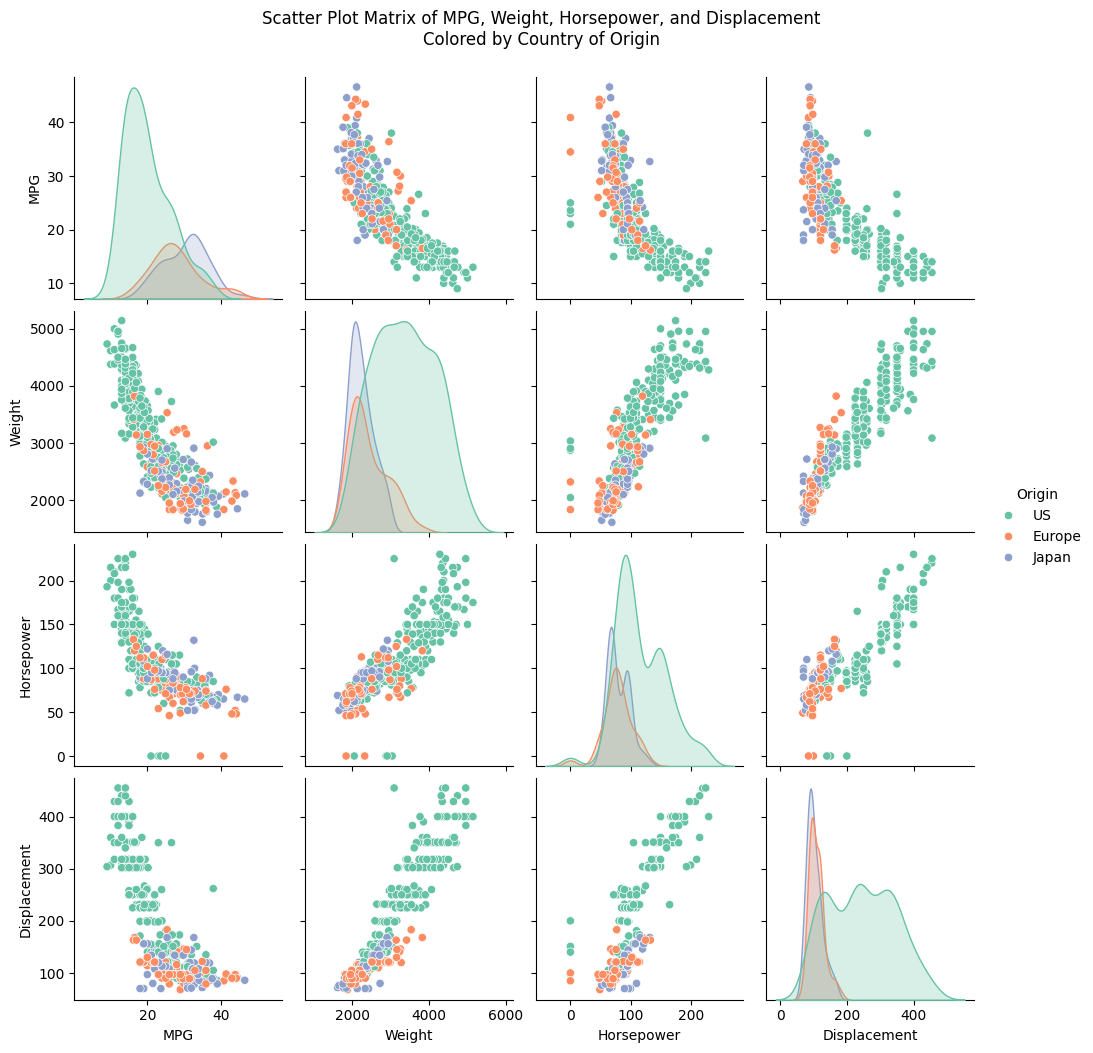

In [12]:
#4
sns.pairplot(data[['MPG', 'Weight', 'Horsepower', 'Displacement', 'Origin']], hue='Origin', palette='Set2')
#pairplot untuk menggelompoka data, hue untuk memberikan warna sesuai Origin, pallete set2 salah satu warna yg di seaborn

# Menampilkan plot
plt.suptitle("Scatter Plot Matrix of MPG, Weight, Horsepower, and Displacement\nColored by Country of Origin", y=1.05)
#plt suptitle untuk memberikan judul utama diseluruh figure, beda dgn plt title yg hanya memberi judul pd 1 figure
#y = 2 penempatan judul suptitle
plt.show()

Dalam grafik tersebut bisa dilihat hubungan antar variabel. Yaitu menampilkan mobil dari berbagai negara yang memiliki karakteristik yang berbeda, seperti 
1. Mobil dari US (hijau) biasanya lebih berat, lebih boros bahan bakar (MPG rendah), dan memiliki displacement (mesin) yang lebih besar.
2. Mobil dari Jepang (biru) cenderung lebih ringan dan lebih hemat bahan bakar (MPG tinggi).
3. Mobil dari Eropa (oranye) berada di tengah-tengah antara kedua pola tersebut.